In [ ]:
import os,sys
from scipy import io
import scanpy as sc
import scvelo as scv
import cellrank as cr
from cellrank.kernels import CytoTRACEKernel
import anndata as ad
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import collections
import matplotlib
import warnings
from scipy.sparse import csr_matrix, diags
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "DejaVu Sans",   # e.g., "Arial", "Helvetica"
    "font.size": 6,
    "axes.titlesize": 6,
    "axes.labelsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "svg.fonttype": "none",         # keep editable text in SVG
})



"""plt.rcParams.update(plt.rcParamsDefault)
rc={"axes.labelsize": 16, "xtick.labelsize": 12, "ytick.labelsize": 12,
    "figure.titleweight":"bold", #"font.size":14,
    "figure.figsize":(5.5,4.2), "font.weight":"regular", "legend.fontsize":10,
    'axes.labelpad':8, 'figure.dpi':300}
plt.rcParams.update(**rc)"""


MTpers=[30,30]
if MTpers[0]==MTpers[1]:
    MTper=MTpers[0]
else:
    MTper=str(MTpers[0]) + "_" + str(MTpers[1])
res=.1
res1=int(res*10**(len(str(res))-2))
dataName="Mesentery"
sampleNames=["WT-HFD","LOF-HFD"]
sn="/combined"
for i in sampleNames:
  sn=sn+"_"+i
sn=sn+"_"+str(MTper)+"_"+str(res1)+"/"
print(sn)
mainDir = '/yourDataAndCodeFolder/'
dataDir = mainDir+"loomFiles/RNA_Velocity/"+dataName+"/"+sn
plotDir = mainDir+'analysis/SCA_plots/'+dataName+"/"+sn+"/rnaVelocity/"
processedDataDir = mainDir+'analysis/processed_files/'+dataName+"/"+sn+"/rnaVelocity/"

if not os.path.exists(plotDir):
    os.mkdir(plotDir)
    
if not os.path.exists(processedDataDir):
    os.mkdir(processedDataDir)

# path='/Users/dongyuzhao/Library/CloudStorage/GoogleDrive-kulandaisamy.arulsamy@enders.tch.harvard.edu/My Drive/Dr_Hongs_data/Analysis/ScRNA_seq/Aorta_western_diet/DS/before_cutoff_backup/mebocost/'
dataNames=["WT-HFD","LOF-HFD"]
dataType='ABC_'
plotMap="umap"
conditionNames="conditions"
cellTypeNames=dataType+'subCellTypes'
cellTypeConditionNames=dataType+'Cond_SCT'
ext='.svg'
os.chdir(dataDir)
!pwd

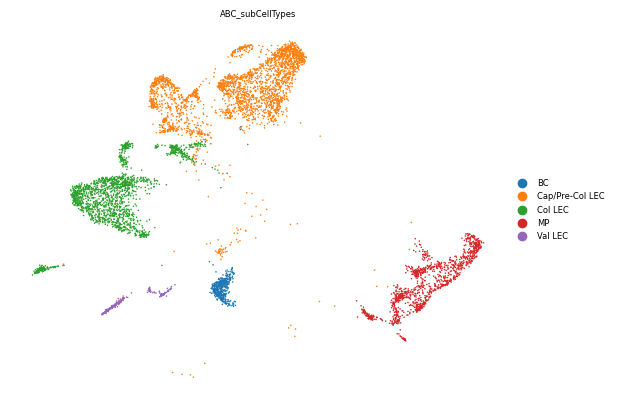

In [3]:
# load sparse matrix:
X = io.mmread(dataDir+"countsF.mtx")

# create anndata object
adata = ad.AnnData(
    X=X.transpose().tocsr()
)

# load cell metadata:
cell_meta = pd.read_csv(dataDir+"metadataF.csv")
cell_meta.index=cell_meta.loc[:,'Unnamed: 0']
del cell_meta['Unnamed: 0']
cell_meta

# load gene names:
with open(dataDir+"gene_namesF.csv", 'r') as f:
    gene_names = f.read().splitlines()

# set anndata observations and index obs by barcodes, var by gene names
adata.obs = cell_meta
adata.obs.index = [bc[0:len(bc)-4] + '_' + cond for bc,cond in zip(adata.obs['barcode'].tolist(),adata.obs[conditionNames].tolist())]
adata.var.index = gene_names

"""# load dimensional reduction:
pca = pd.read_csv(dataDir+dataType+"pca.csv")
pca.index=pca.loc[:,'Unnamed: 0']
del pca['Unnamed: 0']
pca
adata.obsm['X_pca'] = pca.to_numpy()"""

# set pca and umap
adata.obsm['X_pca'] = np.vstack((adata.obs[dataType+'PCA_1'].to_numpy(), adata.obs[dataType+'PCA_2'].to_numpy())).T
adata.obsm['X_tsne'] = np.vstack((adata.obs[dataType+'TSNE_1'].to_numpy(), adata.obs[dataType+'TSNE_2'].to_numpy())).T
adata.obsm['X_umap'] = np.vstack((adata.obs[dataType+'UMAP_1'].to_numpy(), adata.obs[dataType+'UMAP_2'].to_numpy())).T

# plot a UMAP colored by sampleID to test:
sc.pl.umap(adata, color=[cellTypeNames],size=5, frameon=False, save=cellTypeNames)

# save dataset as anndata format
adata.write(processedDataDir+'my_data.h5ad')

In [4]:
ldata1 = scv.read(dataDir+"../../../WT-ND-Mes/"+'possorted_genome_bam_0TZ5W.loom', cache=True)
barcodes = [bc.split(':')[1] for bc in ldata1.obs.index.tolist()]
barcodes = [bc[0:len(bc)-1] + '_WT-ND-Mes' for bc in barcodes]
ldata1.obs.index = barcodes
ldata1.var_names_make_unique()
ldata1

ldata2 = scv.read(dataDir+"../../../WT-HFD-Mes/"+'possorted_genome_bam_1ROXJ.loom', cache=True)
barcodes = [bc.split(':')[1] for bc in ldata2.obs.index.tolist()]
barcodes = [bc[0:len(bc)-1] + '_WT-HFD-Mes' for bc in barcodes]
ldata2.obs.index = barcodes
ldata2.var_names_make_unique()
ldata2

ldata3 = scv.read(dataDir+"../../../LOF-HFD-Mes/"+'possorted_genome_bam_B24R7.loom', cache=True)
barcodes = [bc.split(':')[1] for bc in ldata3.obs.index.tolist()]
barcodes = [bc[0:len(bc)-1] + '_LOF-HFD-Mes' for bc in barcodes]
ldata3.obs.index = barcodes
ldata3.var_names_make_unique()
ldata3

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/krishangupta/opt/anaconda3/envs/cellrank/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/krishangupta/opt/anaconda3/envs/cellrank/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/krishangupta/opt/anaconda3/envs/cellrank/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 4470 × 32285
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced'

In [5]:
adata = sc.read_h5ad(processedDataDir+'my_data.h5ad')

WT=adata.obs[conditionNames].index[adata.obs[conditionNames]==dataNames[0]]
print(WT.shape)
KO=adata.obs[conditionNames].index[adata.obs[conditionNames]==dataNames[1]]
print(WT.shape)


adata_WT=adata[adata.obs[conditionNames]==dataNames[0]]
print(adata_WT.shape)
adata_KO=adata[adata.obs[conditionNames]==dataNames[1]]
print(adata_KO.shape)


adata_WT=scv.utils.merge(adata_WT, ldata2)
print(adata_WT.shape)
adata_KO=scv.utils.merge(adata_KO, ldata3)
print(adata_KO.shape)


adata = adata_WT.concatenate(adata_KO)
print(adata.shape)
adata

# save dataset as anndata format
adata.write(processedDataDir+'my_data_1.h5ad')

(5993,)
(5993,)
(5993, 20622)
(524, 20622)
(5993, 20609)
(524, 20609)
(6517, 20609)


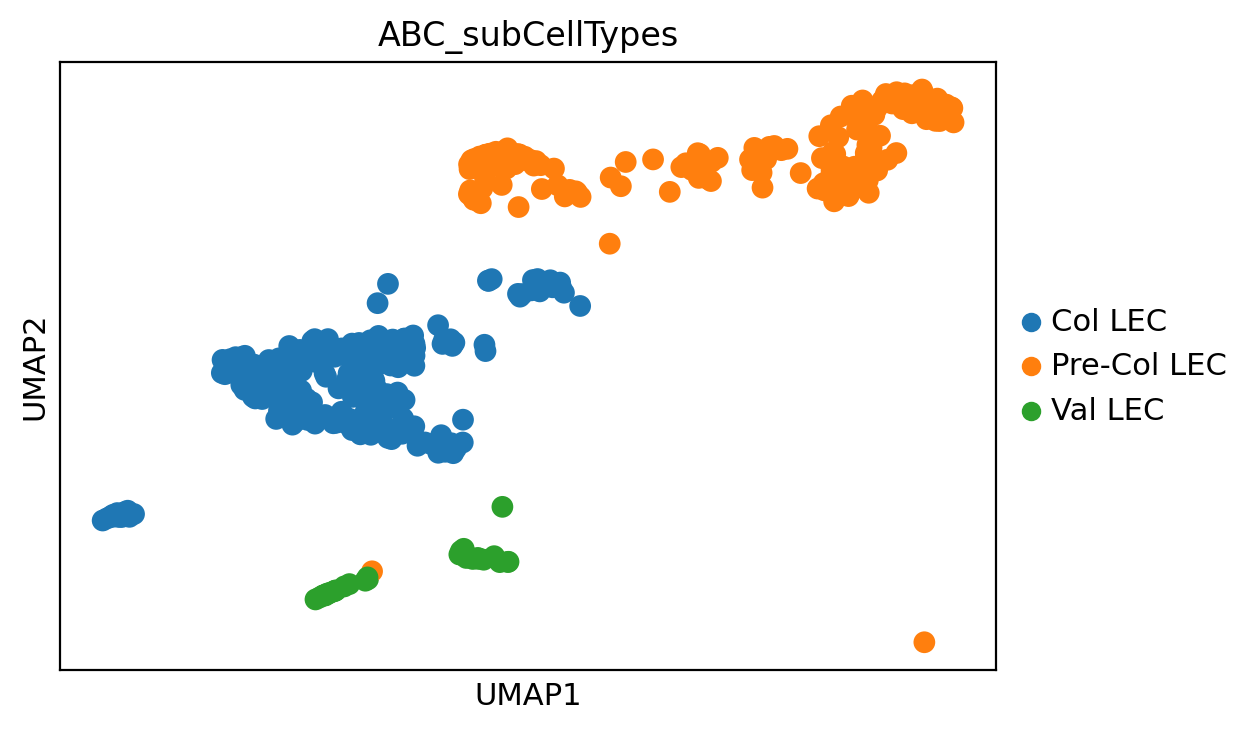

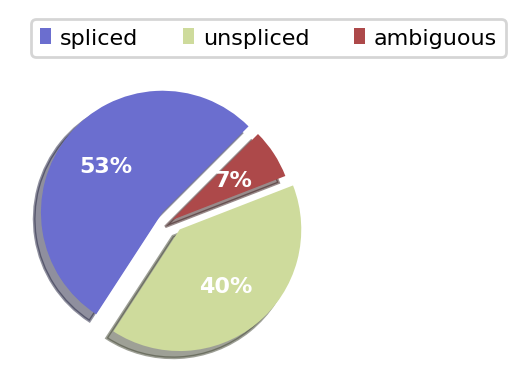

In [8]:
# reload dataset
adata = sc.read_h5ad(processedDataDir+'my_data_1.h5ad')

dataName=dataNames[1]

# cellTypes=['Cap LEC1','Cap LEC2','Cap LEC3',"Col LEC","Val LEC","Ent","PC","MP","BC"][0:5]
cellTypes=['Pre-Col LEC',"Col LEC","Val LEC","Ent","PC","MP","BC"][0:3]
initialState=cellTypes
terminalState=cellTypes

adata = adata[adata.obs[conditionNames].isin([dataName])] # filtering with conditions
adata = adata[adata.obs[cellTypeNames].isin(cellTypes)] # filtering with cellTypes
sc.pl.embedding(adata, basis=plotMap, color=cellTypeNames) # ploting with embeding and cellTypes
scv.settings.verbosity = 3
scv.settings.set_figure_params("scvelo")
cr.settings.verbosity = 2
warnings.simplefilter("ignore", category=UserWarning)
scv.pl.proportions(adata)

# save dataset as anndata format
adata.write(processedDataDir+'my_data_2.h5ad')

# CellRank Meets RNA Velocity

Filtered out 18234 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.


/Users/krishangupta/opt/anaconda3/envs/krishangupta/lib/python3.8/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
recovering dynamics (using 8/16 cores)


  0%|          | 0/843 [00:00<?, ?gene/s]

    finished (0:00:17) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
Computing transition matrix using `'deterministic'` model


  0%|          | 0/490 [00:00<?, ?cell/s]

Using `softmax_scale=6.6870`


  0%|          | 0/490 [00:00<?, ?cell/s]

    Finish (0:00:01)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:00)


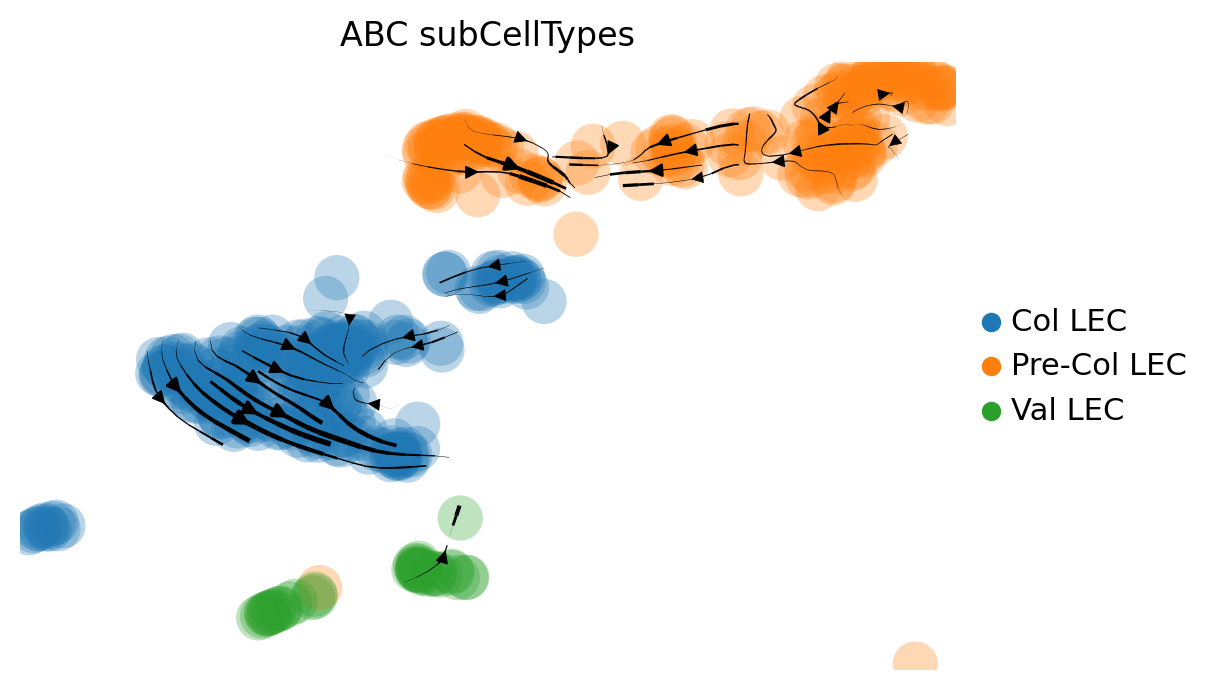

In [9]:
# reload dataset
adata = sc.read_h5ad(processedDataDir+'my_data_2.h5ad')

scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000, subset_highly_variable=True)
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_pcs=30, n_neighbors=30, random_state=0)
scv.pp.moments(adata, n_pcs=None, n_neighbors=None)

scv.tl.recover_dynamics(adata, n_jobs=8)
scv.tl.velocity(adata, mode="dynamical")

vk = cr.kernels.VelocityKernel(adata)
vk.compute_transition_matrix()
vk.plot_projection(color=cellTypeNames,legend_loc="right") # ploting with cellTypes
# vk.plot_random_walks(start_ixs={cellTypeNames: initialState}, max_iter=200, seed=0) # initial state
vk.write_to_adata()
adata.write(processedDataDir+"_"+dataType+'_RNA_velocity.h5ad')